### **III. Data Processing**

### **III.1 Data cleaning**

### **III.1.1. Handling Missing Values in a Time-Series Context**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import MinMaxScaler


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 12

url = "https://raw.githubusercontent.com/dhieu0901/DSEB65A_MachineLearningProject_Group5/main/data/Hanoi%20Daily%2010%20years.csv"

df = pd.read_csv(url)

print("Kích thước dữ liệu (Rows, Columns):", df.shape)
print("\n5 dòng dữ liệu đầu tiên:")
print(df.head())

Kích thước dữ liệu (Rows, Columns): (3660, 33)

5 dòng dữ liệu đầu tiên:
    name   datetime  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
0  Hanoi  9/20/2015     33.0     26.7  29.3          41.7          30.5   
1  Hanoi  9/21/2015     29.5     25.0  26.8          34.4          25.0   
2  Hanoi  9/22/2015     28.5     25.0  25.9          32.8          25.0   
3  Hanoi  9/23/2015     31.3     25.5  28.0          39.7          25.5   
4  Hanoi  9/24/2015     34.5     26.5  29.9          43.5          26.5   

   feelslike   dew  humidity  ...  solarenergy  uvindex  severerisk  \
0       35.4  25.7      81.5  ...         12.2        5         NaN   
1       29.2  24.3      86.3  ...          5.8        3         NaN   
2       26.5  24.2      90.5  ...          7.2        3         NaN   
3       32.0  25.4      86.2  ...         12.1        5         NaN   
4       36.4  25.9      80.4  ...         19.5        8         NaN   

               sunrise               sunset  moon

In [15]:
# ============================================================
# III.1.1. Handling Missing Values
# ============================================================

def check_missing_values(df):
    """Return missing percentage for each column."""
    missing = df.isnull().mean() * 100
    return missing[missing > 0].sort_values(ascending=False)

missing_ratio = check_missing_values(df)
print("\nMissing Value Ratio (%):")
print(missing_ratio)

# Focus on specific columns
if 'severerisk' in df.columns:
    print(f"\nsevererisk missing: {missing_ratio['severerisk']:.2f}%")
if 'preciptype' in df.columns:
    print(f"preciptype missing: {missing_ratio['preciptype']:.2f}%")


Missing Value Ratio (%):
severerisk    72.677596
preciptype    26.967213
dtype: float64

severerisk missing: 72.68%
preciptype missing: 26.97%


### **III.1.2. Removal of Redundant and Zero-Variance Columns**

In [27]:
# ============================================================
# III.1.2. Constant and Zero-Variance Columns
# ============================================================

def find_constant_columns(df):
    """Find columns with only one unique (non-null) value."""
    return [col for col in df.columns if df[col].nunique(dropna=True) <= 1]

constant_cols = find_constant_columns(df)
print("\nConstant Columns Detected:")
print(constant_cols)

# Check variance of numeric columns to find near-zero variance
numeric_df = df.select_dtypes(include=[np.number])
zero_var_cols = [col for col in numeric_df.columns if numeric_df[col].var() == 0]
print("\nZero-Variance Columns (numeric only):")
print(zero_var_cols)
# Combine all redundant columns
redundant_cols = list(set(constant_cols + zero_var_cols))
print("\nRedundant Columns to Drop:")
print(redundant_cols)

# Drop them from the dataset
cleaned_df = df.drop(columns=redundant_cols, errors='ignore')
print("\nDataset shape after dropping redundant columns:")
print("Before:", df.shape, "→ After:", cleaned_df.shape)

# Interpolation test (for temp)
if 'temp' in cleaned_df.columns and 'datetime' in cleaned_df.columns:
    cleaned_df['datetime'] = pd.to_datetime(cleaned_df['datetime'], errors='coerce')
    cleaned_df = cleaned_df.set_index('datetime')

    temp_null_before = cleaned_df['temp'].isnull().sum()
    cleaned_df['temp'] = cleaned_df['temp'].interpolate(method='time')
    temp_null_after = cleaned_df['temp'].isnull().sum()

    print(f"\nInterpolation applied to 'temp': missing before = {temp_null_before}, after = {temp_null_after}")


Constant Columns Detected:
['name', 'preciptype', 'snow', 'snowdepth']

Zero-Variance Columns (numeric only):
['snow', 'snowdepth']

Redundant Columns to Drop:
['name', 'snowdepth', 'snow', 'preciptype']

Dataset shape after dropping redundant columns:
Before: (3660, 33) → After: (3660, 29)

Interpolation applied to 'temp': missing before = 0, after = 0


## **III.2. Correlation Analysis**

### **III.2.1. Correlation Matrix Visualization**


Top Correlated Features with temp:
temp              1.000000
tempmax           0.977442
feelslike         0.973896
tempmin           0.969415
feelslikemax      0.957544
feelslikemin      0.942688
dew               0.903089
severerisk        0.647819
solarradiation    0.615518
solarenergy       0.615312
Name: temp, dtype: float64


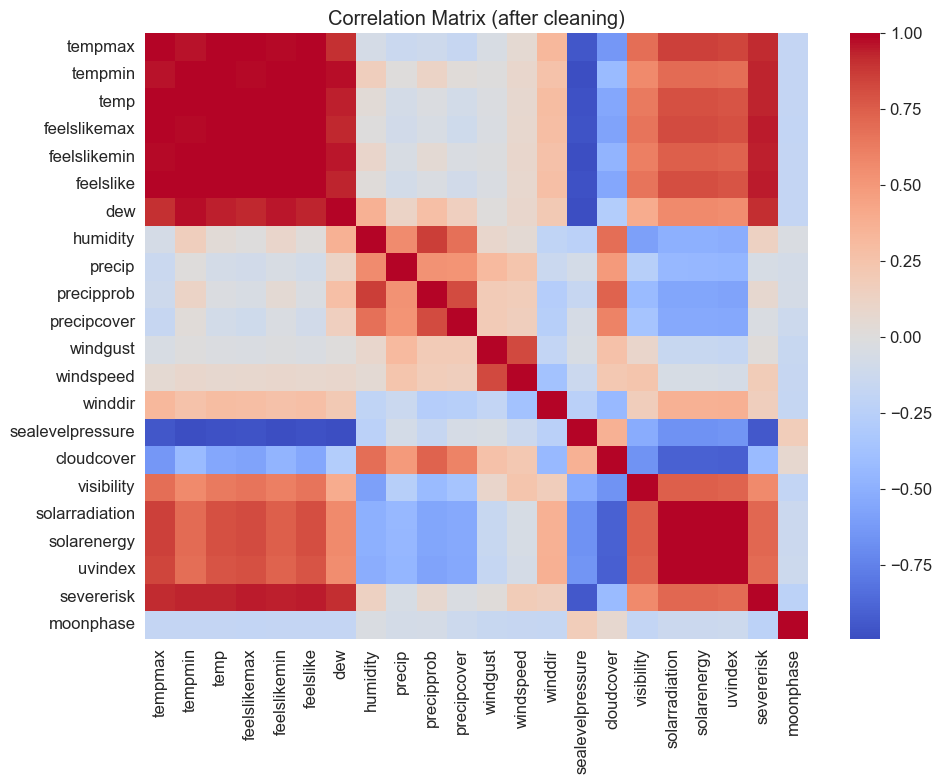

In [28]:
# ============================================================
# III.2.1. Correlation Analysis (Pearson)
# ============================================================

# Select numeric columns
num_df = cleaned_df.select_dtypes(include=[np.number])

# Compute Pearson correlation
corr_matrix = num_df.corr()

# Sort top correlations with temp
top_corr = corr_matrix['temp'].sort_values(ascending=False).head(10)
print("\nTop Correlated Features with temp:")
print(top_corr)

# Optional visualization
def plot_correlation_heatmap(df, figsize=(10, 8), cmap='coolwarm', title="Correlation Matrix (after cleaning)"):
    """
    Plot a correlation matrix heatmap for the given DataFrame.
    """
    corr_matrix = df.corr(numeric_only=True)
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, cmap=cmap, center=0, annot=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_correlation_heatmap(corr_matrix)

### **III.2.2. Key Insights and Multicollinearity**

In [29]:
# ============================================================
# III.2.2. Variance Inflation Factor (VIF)
# ============================================================



def compute_vif(df, features):
    """Compute VIF for selected numeric features."""
    X = df[features].dropna()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = features
    vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
    return vif_data.sort_values(by="VIF", ascending=False)

# Select top correlated features (excluding target)
top_features = [f for f in top_corr.index if f != 'temp'][:8]
vif_table = compute_vif(num_df, top_features)

print("\nVariance Inflation Factor (Top Features):")
print(vif_table)



Variance Inflation Factor (Top Features):
          Feature        VIF
1       feelslike  66.360538
3    feelslikemax  53.828244
2         tempmin  36.252380
4    feelslikemin  28.213845
0         tempmax  27.764826
5             dew  12.109670
7  solarradiation   3.139213
6      severerisk   3.120363


In [30]:
# ============================================================
# III.3. Outlier Detection and Treatment (Using IQR Method)
# ============================================================

# Select numeric columns for analysis
num_df = cleaned_df.select_dtypes(include=[np.number])

# Calculate IQR for each numeric column
Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

# Define acceptable range (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify rows with any feature outside the range
outlier_mask = ~((num_df < lower_bound) | (num_df > upper_bound)).any(axis=1)

before_rows = cleaned_df.shape[0]
cleaned_df = cleaned_df[outlier_mask]
after_rows = cleaned_df.shape[0]

print(f"\nOutlier treatment completed using IQR method.")
print(f"Rows before: {before_rows} → after: {after_rows} (removed {before_rows - after_rows} rows, {(1 - after_rows/before_rows)*100:.2f}% reduction)")


# ============================================================
# III.4. Data Type Validation and Standardization
# ============================================================

# Convert 'datetime' to datetime type and set as index
if 'datetime' in cleaned_df.columns:
    cleaned_df['datetime'] = pd.to_datetime(cleaned_df['datetime'], errors='coerce')
    cleaned_df = cleaned_df.set_index('datetime')

# Ensure numeric columns are float
for col in cleaned_df.select_dtypes(include=[np.number]).columns:
    cleaned_df[col] = cleaned_df[col].astype(float)

# ============================================================
# III.5. Data Normalization and Categorical Encoding
# ============================================================


# Normalize numerical features
scaler = MinMaxScaler()
num_cols = cleaned_df.select_dtypes(include=[np.number]).columns
cleaned_df[num_cols] = scaler.fit_transform(cleaned_df[num_cols])

print("\nNumerical features normalized using Min-Max scaling (range 0–1).")

# Encode categorical variables if present
cat_cols = cleaned_df.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    cleaned_df = pd.get_dummies(cleaned_df, columns=cat_cols, drop_first=True)
    print(f"Categorical columns encoded: {list(cat_cols)}")
else:
    print("No categorical columns detected for encoding.")

# ============================================================
# III.6. Final Validation
# ============================================================

print("\nFinal Dataset Overview:")
print(cleaned_df.info())
print("\nMissing Values Count:", cleaned_df.isnull().sum().sum())
print("\nStatistical Summary:")
print(cleaned_df.describe().T)




Outlier treatment completed using IQR method.
Rows before: 3660 → after: 2257 (removed 1403 rows, 38.33% reduction)

Numerical features normalized using Min-Max scaling (range 0–1).
Categorical columns encoded: ['sunrise', 'sunset', 'conditions', 'description', 'icon', 'stations']

Final Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2257 entries, 2015-09-20 to 2025-09-20
Columns: 4584 entries, tempmax to stations_VVNB,remote
dtypes: bool(4562), float64(22)
memory usage: 10.2 MB
None

Missing Values Count: 1631

Statistical Summary:
                   count      mean       std  min       25%       50%  \
tempmax           2257.0  0.578293  0.209087  0.0  0.424561  0.607018   
tempmin           2257.0  0.618702  0.202040  0.0  0.456067  0.665272   
temp              2257.0  0.597268  0.213336  0.0  0.434426  0.631148   
feelslikemax      2257.0  0.504769  0.238591  0.0  0.298765  0.501235   
feelslikemin      2257.0  0.523411  0.197396  0.0  0.370607  0.530351  